## Part 1 — Julia & Flux.jl Essentials

Workshop series: *Image denoising with Julia and Flux.jl*

| Notebook | Scope |
|---|---|
| **01_julia_flux_basics** | Julia and Flux concepts used in the workshop |
| 02_denoise_training | Data synthesis, encoder–decoder design, training |
| 03_denoise_inference | Model loading and inference on full-size images |

All data is synthesized locally. The notebooks run on a CPU with no GPU required.

In [1]:
using Pkg
Pkg.activate(".")        # project environment in this directory
Pkg.instantiate()

  Activating 

project at `~/ws_julia/Eco-workshop-n8`


### A. Julia essentials for deep learning
Only the language features used later are covered here.

#### A.1 Float32
Flux layers use `Float32` by default. It halves memory compared with `Float64`. Write literals as `1f0` or `0.1f0`.

In [2]:
typeof(1.0), typeof(1f0), sizeof(zeros(Float64, 1000)), sizeof(zeros(Float32, 1000))

(Float64, Float32, 8000, 4000)

#### A.2 Arrays are column-major, and the batch dimension comes last
Indexing is 1-based, and the first index varies fastest in memory. Flux therefore expects:
- Dense layers: `features × batch`
- Conv layers: `width × height × channels × batch` (**WHCN**)

In [3]:
A = reshape(1:12, 3, 4)
A[1, 1], A[end, end], vec(A)'      # vec shows the memory order

(1, 12, adjoint(1:12))

#### A.3 Broadcasting
A trailing `.` applies a function element-wise; `@.` dots an entire expression and fuses it into a single loop.

In [4]:
σ(x) = 1 / (1 + exp(-x))
v = Float32[-2, -1, 0, 1, 2]
σ.(v), @.(3v^2 + σ(v))

(Float32[0.11920292, 0.26894143, 0.5, 0.7310586, 0.880797], Float32[12.119203, 3.2689414, 0.5, 3.7310586, 12.880797])

#### A.4 Callable structs
A Flux layer is a struct holding parameters plus a method that makes it callable. `Dense`, `Conv` and custom layers all follow this pattern.

In [5]:
struct MyAffine
    W::Matrix{Float32}
    b::Vector{Float32}
end
(l::MyAffine)(x) = l.W * x .+ l.b

MyAffine(randn(Float32, 2, 3), zeros(Float32, 2))(rand(Float32, 3))

2-element Vector{Float32}:
 -1.2139895
 -0.23187289

#### A.5 Just-in-time compilation
A function is compiled the first time it is called with new argument types. The first call is slow and later calls are fast, which is why the first training epoch always takes longer.

In [6]:
g(x) = sum(abs2, x) / length(x)
x = rand(Float32, 10^6)
@time g(x);    # includes compilation
@time g(x);    # compiled

  0.011736 seconds (36.91 k allocations: 1.902 MiB, 99.26% compilation time)
  0.000070 seconds (1 allocation: 16 bytes)


### B. Flux building blocks

In [7]:
using Flux, Statistics, Random, Plots
Random.seed!(1234);

#### B.1 Layers and `Chain`

In [8]:
model = Chain(Dense(1 => 32, tanh), Dense(32 => 32, tanh), Dense(32 => 1))

Chain(
  Dense(1 => 32, tanh),                 # 64 parameters
  Dense(32 => 32, tanh),                # 1_056 parameters
  Dense(32 => 1),                       # 33 parameters
)                   # Total: 6 arrays, 1_153 parameters, 4.809 KiB.

In [9]:
model(rand(Float32, 1, 5))    # 1 feature × batch of 5

1×5 Matrix{Float32}:
 -0.338601  -0.202701  -0.0189289  -0.180393  -0.0131547

#### B.2 Automatic differentiation: Zygote or Enzyme

| | Zygote.jl | Enzyme.jl |
|---|---|---|
| Approach | Source-to-source AD on Julia code (ChainRules) | AD at the LLVM compiler level |
| Flux usage | `Flux.gradient(f, model)` (default) | `Flux.gradient(f, Duplicated(model))` |
| Array mutation | Not supported | Supported |
| Compile latency | Low | High for conv networks |
| Typical fit | Standard NN layers | Scientific code with loops and mutation |

**This workshop uses Zygote.** The denoiser is built entirely from standard Flux layers, Zygote has lower compile latency on a laptop, and it is the default. Enzyme is shown below for comparison.

The gradient has the same nested structure as the model:

In [10]:
x = rand(Float32, 1, 16)
y = sin.(3 .* x)
loss(m, x, y) = Flux.mse(m(x), y)

grads = Flux.gradient(m -> loss(m, x, y), model)
size(grads[1].layers[1].weight)

(32, 1)

In [11]:
using Enzyme

@time g_zygote = Flux.gradient(loss, model, x, y)[1]
@time g_enzyme = Flux.gradient(loss, Duplicated(model), Const(x), Const(y))[1]   # first call compiles
g_zygote.layers[1].weight ≈ g_enzyme.layers[1].weight

  0.125839 seconds (400.63 k allocations: 20.897 MiB, 99.73% compilation time)
 13.999811 seconds (42.10 M allocations: 2.233 GiB, 3.48% gc time, 99.99% compilation time)


true

#### B.3 Training loop
1. `Flux.setup(Adam(lr), model)` creates the optimiser state.
2. `Flux.withgradient` returns the loss and its gradient.
3. `Flux.update!` updates the parameters in place.

Example: fitting $y = \sin(3x)$ on synthesized data.

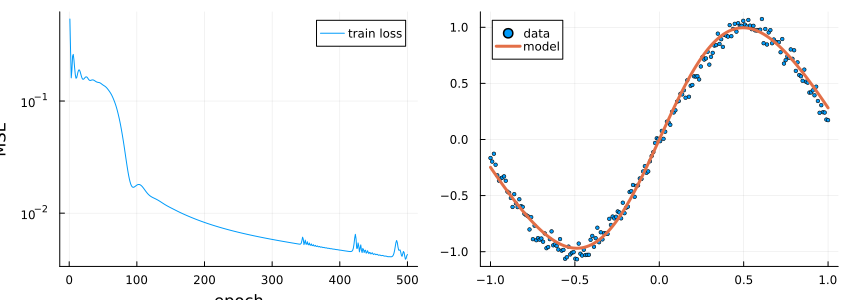

In [12]:
xtrain = reshape(Float32.(range(-1, 1; length=200)), 1, :)
ytrain = sin.(3 .* xtrain) .+ 0.05f0 .* randn(Float32, size(xtrain))

model = Chain(Dense(1 => 32, tanh), Dense(32 => 32, tanh), Dense(32 => 1))
opt_state = Flux.setup(Adam(0.01), model)

losses = Float32[]
for epoch in 1:500
    l, gs = Flux.withgradient(m -> Flux.mse(m(xtrain), ytrain), model)
    Flux.update!(opt_state, model, gs[1])
    push!(losses, l)
end

p1 = plot(losses; yscale=:log10, xlabel="epoch", ylabel="MSE", label="train loss")
p2 = scatter(vec(xtrain), vec(ytrain); ms=2, label="data")
plot!(p2, vec(xtrain), vec(model(xtrain)); lw=3, label="model")
plot(p1, p2; layout=(1, 2), size=(850, 300))

`Flux.DataLoader` splits data into shuffled mini-batches:

In [13]:
loader = Flux.DataLoader((xtrain, ytrain); batchsize=32, shuffle=true)
first(loader) .|> size

((1, 32), (1, 32))

#### B.4 Convolutional layers
Image batches are 4-D `WHCN` arrays.

| Layer | Spatial size | Role |
|---|---|---|
| `Conv((3,3), cin => cout; pad=1)` | unchanged | feature extraction |
| `Conv((3,3), cin => cout; pad=1, stride=2)` | ÷ 2 | encoder (downsampling) |
| `ConvTranspose((4,4), cin => cout; pad=1, stride=2)` | × 2 | decoder (upsampling) |

In [14]:
xb = rand(Float32, 64, 64, 3, 8)                       # 8 RGB images, 64×64
c_same = Conv((3, 3), 3 => 16, relu; pad=1)
c_down = Conv((3, 3), 16 => 32, relu; pad=1, stride=2)
c_up   = ConvTranspose((4, 4), 32 => 16, relu; pad=1, stride=2)

size(xb), size(c_same(xb)), size(c_down(c_same(xb))), size(c_up(c_down(c_same(xb))))

((64, 64, 3, 8), (64, 64, 16, 8), (32, 32, 32, 8), (64, 64, 16, 8))

`Flux.outputsize` works out the output shape without running the computation, which is useful when designing an architecture. Conv weights are shared across pixel positions, so each layer has only `k × k × cin × cout + cout` parameters.

In [15]:
Flux.outputsize(Chain(c_same, c_down, Conv((3, 3), 32 => 32; pad=1, stride=2)), (64, 64, 3, 1)) |> println
sum(length, Flux.trainables(c_same)) == 3*3*3*16 + 16

(16

, 16, 32, 1)


true

#### B.5 Composition and custom layers
- `SkipConnection(layer, combine)` computes `combine(layer(x), x)`. It is used for residual connections.
- `Flux.@layer` registers the trainable fields of a custom struct.

In [16]:
res = SkipConnection(Chain(Conv((3,3), 8 => 8, relu; pad=1), Conv((3,3), 8 => 8; pad=1)), +)
size(res(rand(Float32, 16, 16, 8, 1)))

(16, 16, 8, 1)

In [17]:
struct ChannelScale
    s::Vector{Float32}
end
ChannelScale(c::Integer) = ChannelScale(ones(Float32, c))
(l::ChannelScale)(x) = x .* reshape(l.s, 1, 1, :, 1)
Flux.@layer ChannelScale

m = Chain(Conv((3,3), 3 => 4; pad=1), ChannelScale(4))
Flux.gradient(m -> sum(m(rand(Float32, 8, 8, 3, 1))), m)[1].layers[2]

(s = Float32[10.194763, -4.2318597, -11.639894, -14.083785],)

#### B.6 Saving and loading
Save the model **state**, not the object. To load it, rebuild the architecture and then copy the weights in:
```julia
using JLD2
jldsave("model.jld2"; model_state = Flux.state(model))
model = build_model()
Flux.loadmodel!(model, JLD2.load("model.jld2", "model_state"))
```

### Summary

| Concept | Julia / Flux |
|---|---|
| Layer | callable struct: `Dense`, `Conv`, `Flux.@layer` |
| Model | `Chain`, `SkipConnection` |
| Gradient | `Flux.gradient`, `Flux.withgradient` (Zygote; `Duplicated` for Enzyme) |
| Optimisation | `Flux.setup`, `Flux.update!` |
| Data | `DataLoader`, WHCN `Float32` arrays |
| Persistence | `Flux.state`, `Flux.loadmodel!`, JLD2 |

Next: **02_denoise_training.ipynb**